# 086 — Calibrating the low-complexity k-mer mask as a *fraction*, not a count

**Question.** kmerseek's HP alphabets collapse 20 amino acids to 2 letters, which makes
low-complexity k-mers both common and nearly evidence-free. We want a mask that drops them.
The question is what the mask's knob should be, and where to set it.

**Why a fraction and not a count.** What makes a k-mer dangerous is its *per-k-mer database
frequency*: a k-mer present in a large share of sequences gives almost no evidence when
shared, and inflates the Poisson rate kmerseek's p-value model assumes is small. Minority
count works as a proxy for that frequency because compositions of higher complexity are
spread over exponentially more distinct k-mers, so each individual one is rarer — and
disordered regions overproduce the low-complexity ones on top of that, sharpening the drop.

"Spread over exponentially more distinct k-mers" is exactly the binomial coefficient. The
number of distinct HP k-mers with minority count $m$ is $\binom{k}{m}$, and

$$\frac{1}{k}\log_2\binom{k}{m} \;\longrightarrow\; H(m/k)$$

as $k$ grows, where $H$ is binary Shannon entropy. The left-hand side is SEG's compositional
complexity in bits per residue (Wootton & Federhen 1993, *Comput. Chem.* 17:149–163), taken
on the multinomial and specialised here to the binomial. So a complexity cutoff $K^\*$ — the
natural HP analogue of SEG's mask — is equivalent to a minority-count floor

$$m^\*(k) \;=\; \min\{\, m : \tfrac{1}{k}\log_2\tbinom{k}{m} \ge K^\* \,\}$$

and, because the criterion converges to $H(m/k) \ge K^\*$, it holds the minority *fraction*
roughly fixed. **Entropy cutoff, fraction floor, and count floor are three encodings of the
same one-parameter family; the fraction is the interpretable one.** A fixed count silently
admits lower-complexity k-mers as $k$ rises — that drift is the bug this notebook is written
to avoid.

**How the value gets set.** Not by assertion. Two independent routes, which should agree:

1. **The null (primary).** Take the k-mers that generate hits which *shouldn't exist*, look
   at their complexity distribution, and put $K^\*$ where the spurious-hit rate collapses
   below a target false-positive level. This ties the mask directly to the FP rate we care
   about, on our own benchmark, with no free parameter left dangling.
2. **The frequency knee (cross-check).** Build the HP k-mer frequency table over SCOPe40 and
   plot per-k-mer database frequency against minority count. The poly-dominant classes should
   sit orders of magnitude above the rest; $m^\*$ belongs just above that knee.

**The null.** `nextflow-runs/scope40-lowcomplexity-null` searches 10 dipeptide-preserving
(Altschul–Erikson) shuffles of SCOPe40 with the *real* HP alphabets, so every hit is a false
positive by construction while each domain keeps its own residue and dipeptide composition —
low-complexity k-mers are still generated at the rate the real database generates them. This
is deliberately **not** the shuffled-*alphabet* control from notebooks 075–077: there the
sequences are real proteins, so same-family hits remain genuine and the k-mers come from
random H/P partitions rather than from the alphabet the mask ships in. Those runs appear here
only as an independent cross-check.

**Relation to notebook 085.** 085 concluded the search-time gate should be an absolute count,
`n_intersecting_hashes` ≥ 2–3, because ratio scores are length-confounded, and traced short
queries' background hits to *a single coincidental k-mer*. This notebook attacks the same
noise from the other side — making those coincidental k-mers not exist. Part 6 measures the
two filters jointly rather than assuming they compose.

In [1]:
import sys
import warnings
from math import comb, log2
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl

warnings.filterwarnings('ignore', category=FutureWarning)

# Complexity helpers live with the pipeline that produced the data, so the
# notebook and the Nextflow tasks cannot drift apart on the definition of m*.
PIPELINE_BIN = Path.cwd().parent / 'nextflow-runs' / 'scope40-lowcomplexity-null' / 'bin'
sys.path.insert(0, str(PIPELINE_BIN))
from hp_alphabets import HP_TABLES, complexity_bits, h_fraction, label_for, m_star  # noqa: E402

# ---------------------------------------------------------------------------
# Paths. RESULTS_DIR is the full pipeline run; the 300-sequence smoke-test
# output is used as a fallback purely so the notebook is runnable before the
# full run finishes — every number it produces at that size is meaningless.
# ---------------------------------------------------------------------------
FULL_DIR = Path.home() / 'data/scope/results-lowcomplexity-null'
TEST_DIR = Path.cwd().parent / 'nextflow-runs/scope40-lowcomplexity-null/results-test'
RESULTS_DIR = FULL_DIR if (FULL_DIR / 'hits.parquet').exists() else TEST_DIR
IS_SMOKE_TEST = RESULTS_DIR == TEST_DIR

FIG_PREFIX = Path('../figures/086')
Path('../figures').mkdir(exist_ok=True)

if IS_SMOKE_TEST:
    print('=' * 78)
    print('SMOKE-TEST DATA (300 sequences, 2 alphabets, 2 shuffles).')
    print('Structure only — every calibrated number below is noise at this size.')
    print(f'Run the full pipeline, then re-execute:')
    print('  cd ../nextflow-runs/scope40-lowcomplexity-null && make run')
    print('=' * 78)
print(f'reading: {RESULTS_DIR}')

# ---------------------------------------------------------------------------
# Palette: reference categorical slots 1-6 in fixed order, one per alphabet.
# Validated colourblind-safe (worst adjacent CVD dE 9.1 protan, normal 19.6).
# Colour follows the alphabet, never its rank, so filtering never repaints.
# ---------------------------------------------------------------------------
ALPHABET_ORDER = [
    'hp_lehninger',
    'hp_thomas_dill',
    'hp_kyte_doolittle',
    'hp_thomas_dill_no_c',
    'hp_lehninger_plus_c',
    'hp_pbotc_1st_ed',
]
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
ALPHABET_COLOR = dict(zip(ALPHABET_ORDER, PALETTE))

# Semantic colours for the three hit populations. These are roles, not series:
# the null is the thing being suppressed, TPs the thing being protected.
C_NULL, C_TP, C_REALFP = '#eb6834', '#2a78d6', '#8a8a85'

INK, INK_MUTED, GRID = '#0b0b0b', '#52514e', '#d8d8d4'
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': INK_MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.grid': True,
    'font.size': 9, 'axes.titlesize': 10, 'legend.frameon': False,
    'axes.axisbelow': True, 'lines.linewidth': 2, 'lines.markersize': 5,
})

KSIZES_PLANNED = [22, 24, 26, 28]
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)

reading: /Users/olga/data/scope/results-lowcomplexity-null


polars.config.Config

## Part 0 — The one-parameter family, before any data

Three encodings of the same knob. This part is pure combinatorics: it needs no pipeline
output and holds for any two-letter alphabet.

First, reproduce the complexity ladder at k=26, then show the thing that motivates phrasing
the rule as a fraction — **what a *fixed count* does as k moves**.

**One caveat, stated up front so the figure isn't oversold.** A fixed $K^\*$ does not hold
$\alpha$ perfectly constant either. Stirling gives

$$\tfrac{1}{k}\log_2\tbinom{k}{m} \;=\; H(m/k) \;-\; \frac{\log_2(2\pi k pq)}{2k} \;+\; O(k^{-2}),$$

so the finite-$k$ correction is negative and decays only as $O(\log k / k)$: reaching a given
$K^\*$ needs slightly *more* minority at small $k$, and $\alpha$ relaxes toward the asymptote
$H^{-1}(K^\*)$ from above. The integer-valued $m^\*$ adds a sawtooth on top.

So the honest claim is not "fixed $K^\*$ is invariant and fixed count is not." It is that
**the fixed-count drift is large and systematic — always admitting lower complexity as $k$
grows — while the fixed-$K^\*$ residual is small and mostly rounding.** The cell below
quantifies both rather than leaving it to the eye.

**And that quantification has a consequence for this notebook's k range.** Over the
calibrated window k=22–28 the two rules are nearly indistinguishable (fixed-count complexity
drift only ~1.2x the fixed-$K^\*$ drift); over k=12–50 the gap opens to ~4.1x. So the
empirical runs at k=22–28 **cannot by themselves adjudicate fraction vs count** — Part 4's
invariance test has little lever arm at this spacing. The fraction framing is carried by the
combinatorics here in Part 0, which is exact at every $k$ and needs no data; the pipeline runs
supply the *value* of $K^\*$, not the *form* of the rule. If the form itself needs an empirical
defence, widen `params.ksizes` in the pipeline (e.g. `[16, 20, 26, 32, 40]`) and re-run —
Part 4 then has something to separate.

In [2]:
# --- the complexity ladder at k = 26 ---
ladder = pl.DataFrame({
    'm': list(range(1, 9)),
}).with_columns([
    pl.col('m').map_elements(lambda m: comb(26, m), return_dtype=pl.Int64).alias('C(26, m)'),
    pl.col('m').map_elements(lambda m: complexity_bits(26, m), return_dtype=pl.Float64)
      .round(3).alias('bits/residue'),
    (pl.col('m') / 26).round(3).alias('minority fraction'),
])
print('Complexity ladder, k = 26')
print(ladder)

K_STAR_DEMO = 0.6
print(f'\nAt K* = {K_STAR_DEMO} bits/residue:')
for k in [22, 24, 26, 28, 40]:
    ms = m_star(k, K_STAR_DEMO)
    print(f'  k={k:>2d}   m* = {ms:>2d}   alpha = {ms / k:.3f}   '
          f'({complexity_bits(k, ms):.3f} bits)')

print(f'\nIf instead the *count* is pinned at m = 5:')
for k in [22, 24, 26, 28, 40]:
    print(f'  k={k:>2d}   alpha = {5 / k:.3f}   ({complexity_bits(k, 5):.3f} bits)')

# Quantify both drifts instead of asserting one is flat. Reported over the
# calibrated window and over a wide window, since the two differ in kind:
# the fixed-count drift is monotone, the fixed-K* residual is not.
def spread(vals):
    return max(vals) - min(vals)

for lo, hi, name in [(22, 28, 'calibrated window k=22-28'), (12, 50, 'wide window k=12-50')]:
    ks = list(range(lo, hi + 1))
    a_kstar = [m_star(k, K_STAR_DEMO) / k for k in ks]
    a_count = [5 / k for k in ks]
    b_kstar = [complexity_bits(k, m_star(k, K_STAR_DEMO)) for k in ks]
    b_count = [complexity_bits(k, 5) for k in ks]
    print(f'\n{name}')
    print(f'  fixed K*={K_STAR_DEMO}: alpha {min(a_kstar):.3f}-{max(a_kstar):.3f} '
          f'(spread {spread(a_kstar):.3f}), bits spread {spread(b_kstar):.3f}')
    print(f'  fixed m=5     : alpha {min(a_count):.3f}-{max(a_count):.3f} '
          f'(spread {spread(a_count):.3f}), bits spread {spread(b_count):.3f}')
    print(f'  -> fixed-count complexity drift is '
          f'{spread(b_count) / max(spread(b_kstar), 1e-9):.1f}x larger')

Complexity ladder, k = 26
shape: (8, 4)
┌─────┬──────────┬──────────────┬───────────────────┐
│ m   ┆ C(26, m) ┆ bits/residue ┆ minority fraction │
│ --- ┆ ---      ┆ ---          ┆ ---               │
│ i64 ┆ i64      ┆ f64          ┆ f64               │
╞═════╪══════════╪══════════════╪═══════════════════╡
│ 1   ┆ 26       ┆ 0.181        ┆ 0.038             │
│ 2   ┆ 325      ┆ 0.321        ┆ 0.077             │
│ 3   ┆ 2600     ┆ 0.436        ┆ 0.115             │
│ 4   ┆ 14950    ┆ 0.533        ┆ 0.154             │
│ 5   ┆ 65780    ┆ 0.616        ┆ 0.192             │
│ 6   ┆ 230230   ┆ 0.685        ┆ 0.231             │
│ 7   ┆ 657800   ┆ 0.743        ┆ 0.269             │
│ 8   ┆ 1562275  ┆ 0.791        ┆ 0.308             │
└─────┴──────────┴──────────────┴───────────────────┘

At K* = 0.6 bits/residue:
  k=22   m* =  5   alpha = 0.227   (0.667 bits)
  k=24   m* =  5   alpha = 0.208   (0.641 bits)
  k=26   m* =  5   alpha = 0.192   (0.616 bits)
  k=28   m* =  6   alpha = 0.214 

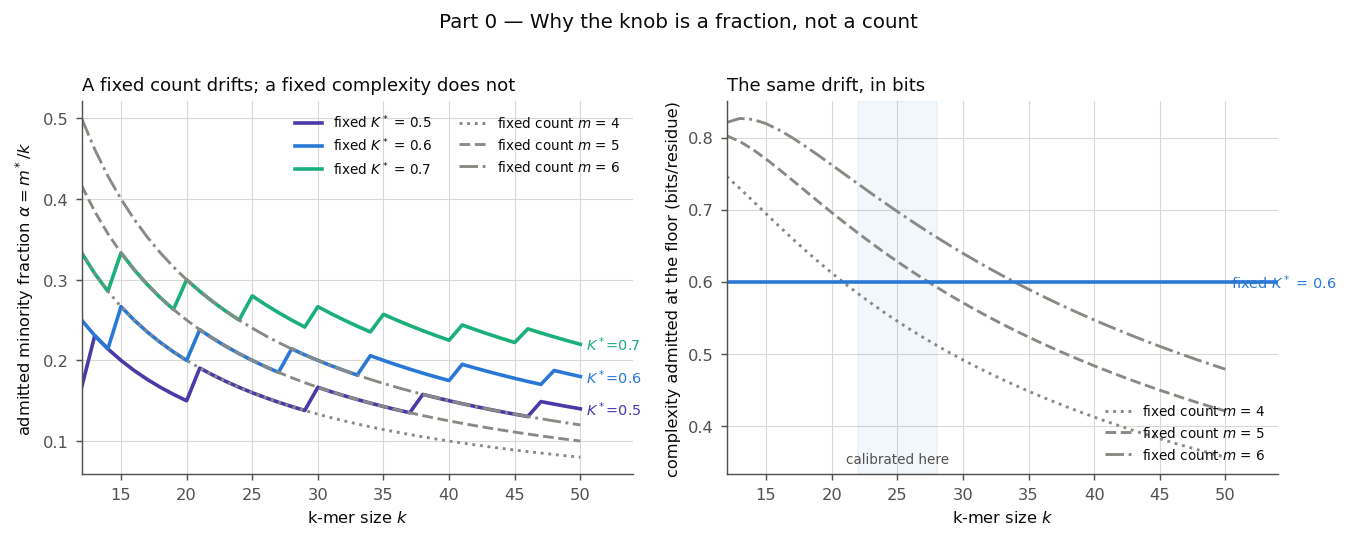

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
k_grid = np.arange(12, 51)

# --- left: what each rule does to the admitted minority fraction ---
ax = axes[0]
for k_star, color in zip([0.5, 0.6, 0.7], ['#4a3aa7', '#2a78d6', '#1baf7a']):
    alpha = [m_star(int(k), k_star) / k for k in k_grid]
    ax.plot(k_grid, alpha, color=color, label=f'fixed $K^*$ = {k_star}')
    ax.annotate(f'$K^*$={k_star}', xy=(k_grid[-1], alpha[-1]), xytext=(3, 0),
                textcoords='offset points', color=color, fontsize=8, va='center')
for fixed_m, style in zip([4, 5, 6], [':', '--', '-.']):
    ax.plot(k_grid, fixed_m / k_grid, color=C_REALFP, linestyle=style,
            linewidth=1.6, label=f'fixed count $m$ = {fixed_m}')
ax.set_xlabel('k-mer size $k$')
ax.set_ylabel('admitted minority fraction $\\alpha = m^*/k$')
ax.set_title('A fixed count drifts; a fixed complexity does not', loc='left')
ax.legend(fontsize=7.5, loc='upper right', ncol=2)
ax.set_xlim(12, 54)

# --- right: the same drift read as bits, which is what "complexity" means ---
ax = axes[1]
for fixed_m, style in zip([4, 5, 6], [':', '--', '-.']):
    bits = [complexity_bits(int(k), fixed_m) for k in k_grid]
    ax.plot(k_grid, bits, color=C_REALFP, linestyle=style, linewidth=1.6,
            label=f'fixed count $m$ = {fixed_m}')
ax.axhline(K_STAR_DEMO, color='#2a78d6', linewidth=2)
ax.annotate(f'fixed $K^*$ = {K_STAR_DEMO}', xy=(k_grid[-1], K_STAR_DEMO), xytext=(3, 0),
            textcoords='offset points', color='#2a78d6', fontsize=8, va='center')
ax.axvspan(22, 28, color='#2a78d6', alpha=0.06)
ax.annotate('calibrated here', xy=(25, ax.get_ylim()[0]), xytext=(0, 6),
            textcoords='offset points', ha='center', fontsize=7.5, color=INK_MUTED)
ax.set_xlabel('k-mer size $k$')
ax.set_ylabel('complexity admitted at the floor (bits/residue)')
ax.set_title('The same drift, in bits', loc='left')
ax.legend(fontsize=7.5, loc='lower right')
ax.set_xlim(12, 54)

fig.suptitle('Part 0 — Why the knob is a fraction, not a count', x=0.5, y=1.02,
             fontsize=11, ha='center')
fig.tight_layout()
fig.savefig(f'{FIG_PREFIX}_fixed_count_drift.png')
plt.show()

## Part 1 — Is the null actually a null?

Before reading anything off the shuffles, check the two properties the calibration depends on.

1. **Composition is preserved.** The shuffle must keep every domain's residue *and* dipeptide
   composition, or the low-complexity k-mers under study are destroyed by the null itself and
   the whole calibration understates the danger. (`shuffle_fasta.py` fails hard on violation;
   this re-reads the reports.)
2. **Homology is destroyed.** Real SCOPe hits should be strongly enriched for same-fold pairs;
   shuffled hits should show no fold signal beyond the base rate. If shuffled hits *were*
   fold-enriched, they would not be "hits that shouldn't exist" and could not define the null.

In [4]:
hits = pl.read_parquet(RESULTS_DIR / 'hits.parquet')
kmers_by_m = pl.read_parquet(RESULTS_DIR / 'kmers_by_minority.parquet')
freq_by_m = pl.read_parquet(RESULTS_DIR / 'freq_by_minority.parquet')
run_stats = pl.read_csv(RESULTS_DIR / 'run_stats.tsv', separator='\t')

ALPHABETS = [a for a in ALPHABET_ORDER if a in set(hits['alphabet'])]
KSIZES = sorted(set(hits['ksize'].to_list()))
SHUFFLE_SETS = sorted({s for s in hits['seqset'] if s.startswith('shuf')})
print(f'alphabets : {ALPHABETS}')
print(f'k-sizes   : {KSIZES}')
print(f'shuffles  : {len(SHUFFLE_SETS)}  ({", ".join(SHUFFLE_SETS)})')
print(f'hits      : {len(hits):,} rows')

# All-vs-all self-search reports each pair twice (A->B and B->A). Collapse to
# one row per unordered pair so hit *counts* are not doubled; the m_hist is
# identical in both directions, so keeping either is lossless.
hits = (
    hits.with_columns([
        pl.min_horizontal('query_domain', 'target_domain').alias('_a'),
        pl.max_horizontal('query_domain', 'target_domain').alias('_b'),
    ])
    .unique(subset=['seqset', 'alphabet', 'ksize', '_a', '_b'], keep='first')
    .drop(['_a', '_b'])
)
print(f'after collapsing reciprocal pairs: {len(hits):,} rows')

shuffle_report_path = RESULTS_DIR / 'shuffle_reports.tsv'
if shuffle_report_path.exists():
    rep = pl.read_csv(shuffle_report_path, separator='\t')
    n_seq = rep['n_sequences'].cast(pl.Int64)
    ok_comp = (rep['n_composition_preserved'].cast(pl.Int64) == n_seq).all()
    ok_di = (rep['n_dipeptide_preserved'].cast(pl.Int64) == n_seq).all()
    print(f'\nshuffles: composition preserved in all sequences: {ok_comp}')
    print(f'shuffles: dipeptide  preserved in all sequences: {ok_di}')
    print(f'shuffles: sequences returned unchanged: '
          f'{rep["n_identical_to_input"].cast(pl.Int64).sum()} / {n_seq.sum()}')
    assert ok_comp and ok_di, 'shuffle did not preserve composition — null is invalid'

bad = run_stats.filter(pl.col('encoding_check_mismatches').fill_null(0) > 0)
print(f'\nHP-encoding cross-checks failed: {len(bad)} tasks (must be 0)')
assert len(bad) == 0, 'Python HP tables disagree with kmerseek moltype_seq'

alphabets : ['hp_lehninger', 'hp_thomas_dill', 'hp_kyte_doolittle', 'hp_thomas_dill_no_c', 'hp_lehninger_plus_c', 'hp_pbotc_1st_ed']
k-sizes   : [22, 24, 26, 28]
shuffles  : 10  (shuf01, shuf02, shuf03, shuf04, shuf05, shuf06, shuf07, shuf08, shuf09, shuf10)
hits      : 106,891,421 rows


after collapsing reciprocal pairs: 53,444,326 rows

shuffles: composition preserved in all sequences: True
shuffles: dipeptide  preserved in all sequences: True
shuffles: sequences returned unchanged: 14 / 151770

HP-encoding cross-checks failed: 0 tasks (must be 0)


In [5]:
# Fold enrichment: the base rate is the same-fold share among *all* domain pairs,
# approximated per seqset by the SCOP composition the hits were drawn from.
fold_tbl = (
    hits.group_by(['alphabet', 'ksize', 'seqset'])
    .agg([
        pl.len().alias('n_hits'),
        pl.col('same_fold').fill_null(False).mean().alias('frac_same_fold'),
        pl.col('same_superfamily').fill_null(False).mean().alias('frac_same_sf'),
        pl.col('n_intersecting_hashes').mean().alias('mean_n_kmers'),
    ])
    .with_columns(
        pl.when(pl.col('seqset') == 'real').then(pl.lit('real'))
          .otherwise(pl.lit('shuffled')).alias('kind')
    )
)

summary = (
    fold_tbl.group_by(['alphabet', 'ksize', 'kind'])
    .agg([
        pl.col('n_hits').mean().round(0).alias('mean_n_hits'),
        pl.col('frac_same_fold').mean().round(4).alias('mean_frac_same_fold'),
        pl.col('mean_n_kmers').mean().round(2).alias('mean_kmers_per_hit'),
    ])
    .sort(['alphabet', 'ksize', 'kind'])
)
print('Hit volume and fold signal, real vs shuffled')
print(summary)

Hit volume and fold signal, real vs shuffled
shape: (48, 6)
┌─────────────────────┬───────┬──────────┬─────────────┬─────────────────────┬────────────────────┐
│ alphabet            ┆ ksize ┆ kind     ┆ mean_n_hits ┆ mean_frac_same_fold ┆ mean_kmers_per_hit │
│ ---                 ┆ ---   ┆ ---      ┆ ---         ┆ ---                 ┆ ---                │
│ str                 ┆ i32   ┆ str      ┆ f64         ┆ f64                 ┆ f64                │
╞═════════════════════╪═══════╪══════════╪═════════════╪═════════════════════╪════════════════════╡
│ hp_kyte_doolittle   ┆ 22    ┆ real     ┆ 1.042196e6  ┆ 0.0168              ┆ 2.1                │
│ hp_kyte_doolittle   ┆ 22    ┆ shuffled ┆ 1.139214e6  ┆ 0.0112              ┆ 2.1                │
│ hp_kyte_doolittle   ┆ 24    ┆ real     ┆ 290638.0    ┆ 0.0222              ┆ 2.11               │
│ hp_kyte_doolittle   ┆ 24    ┆ shuffled ┆ 320856.0    ┆ 0.0114              ┆ 2.1                │
│ hp_kyte_doolittle   ┆ 26    ┆ real    

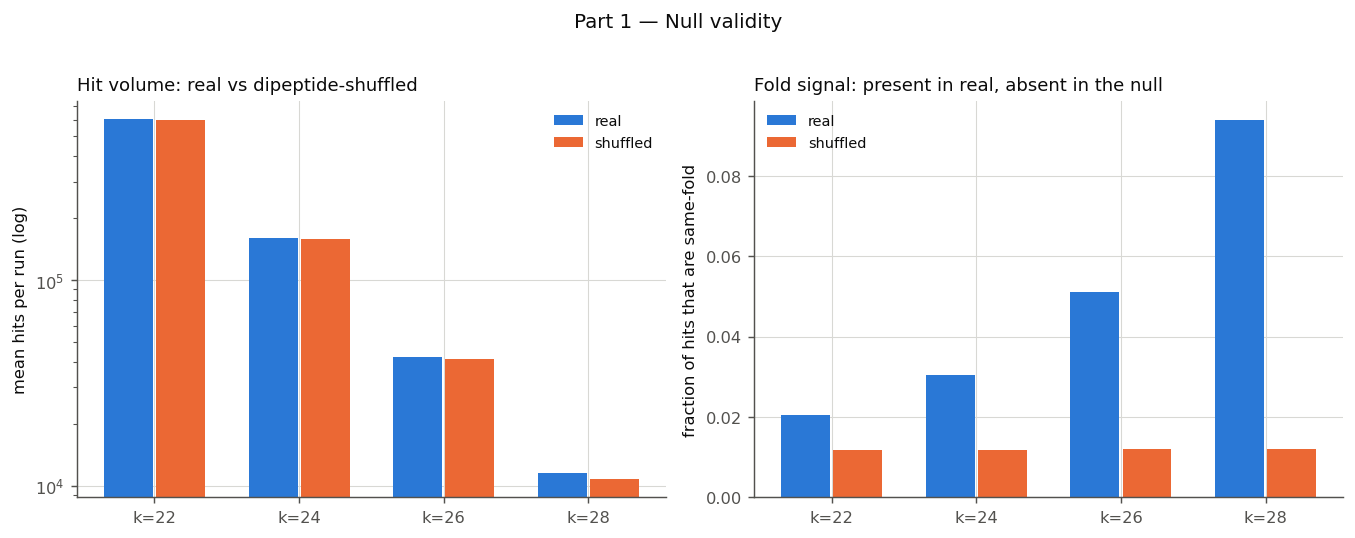

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), sharex=True)
x = np.arange(len(KSIZES))
width = 0.36

# --- left: hit volume collapses on the null ---
ax = axes[0]
for i, (kind, color) in enumerate([('real', C_TP), ('shuffled', C_NULL)]):
    vals = [
        summary.filter((pl.col('kind') == kind) & (pl.col('ksize') == k))['mean_n_hits'].mean()
        for k in KSIZES
    ]
    vals = [v if v is not None else np.nan for v in vals]
    ax.bar(x + (i - 0.5) * width, vals, width * 0.94, color=color, label=kind,
           linewidth=0)
ax.set_yscale('log')
ax.set_xticks(x, [f'k={k}' for k in KSIZES])
ax.set_ylabel('mean hits per run (log)')
ax.set_title('Hit volume: real vs dipeptide-shuffled', loc='left')
ax.legend(fontsize=8)

# --- right: fold signal must vanish on the null ---
ax = axes[1]
for i, (kind, color) in enumerate([('real', C_TP), ('shuffled', C_NULL)]):
    vals = [
        summary.filter((pl.col('kind') == kind) & (pl.col('ksize') == k))
        ['mean_frac_same_fold'].mean()
        for k in KSIZES
    ]
    vals = [v if v is not None else np.nan for v in vals]
    ax.bar(x + (i - 0.5) * width, vals, width * 0.94, color=color, label=kind,
           linewidth=0)
ax.set_xticks(x, [f'k={k}' for k in KSIZES])
ax.set_ylabel('fraction of hits that are same-fold')
ax.set_title('Fold signal: present in real, absent in the null', loc='left')
ax.legend(fontsize=8)

fig.suptitle('Part 1 — Null validity', x=0.5, y=1.02, fontsize=11, ha='center')
fig.tight_layout()
fig.savefig(f'{FIG_PREFIX}_null_validity.png')
plt.show()

## Part 2 — The complexity distribution of the k-mers that cause spurious hits

The premise behind the whole mask is that spurious hits are driven by *low-complexity*
k-mers. That premise is testable, and this is the test: compare the minority-fraction
distribution of the matched k-mers behind

- **null hits** (shuffled sequences — false positives by construction),
- **real true positives** (same superfamily),
- **real false positives** (different fold).

If null-hit k-mers are shifted to low minority fraction relative to real true positives,
a complexity mask has something to bite on. **If the two distributions overlap, no threshold
on this axis can separate them and the mask idea fails** — that outcome is reported here
rather than assumed away.

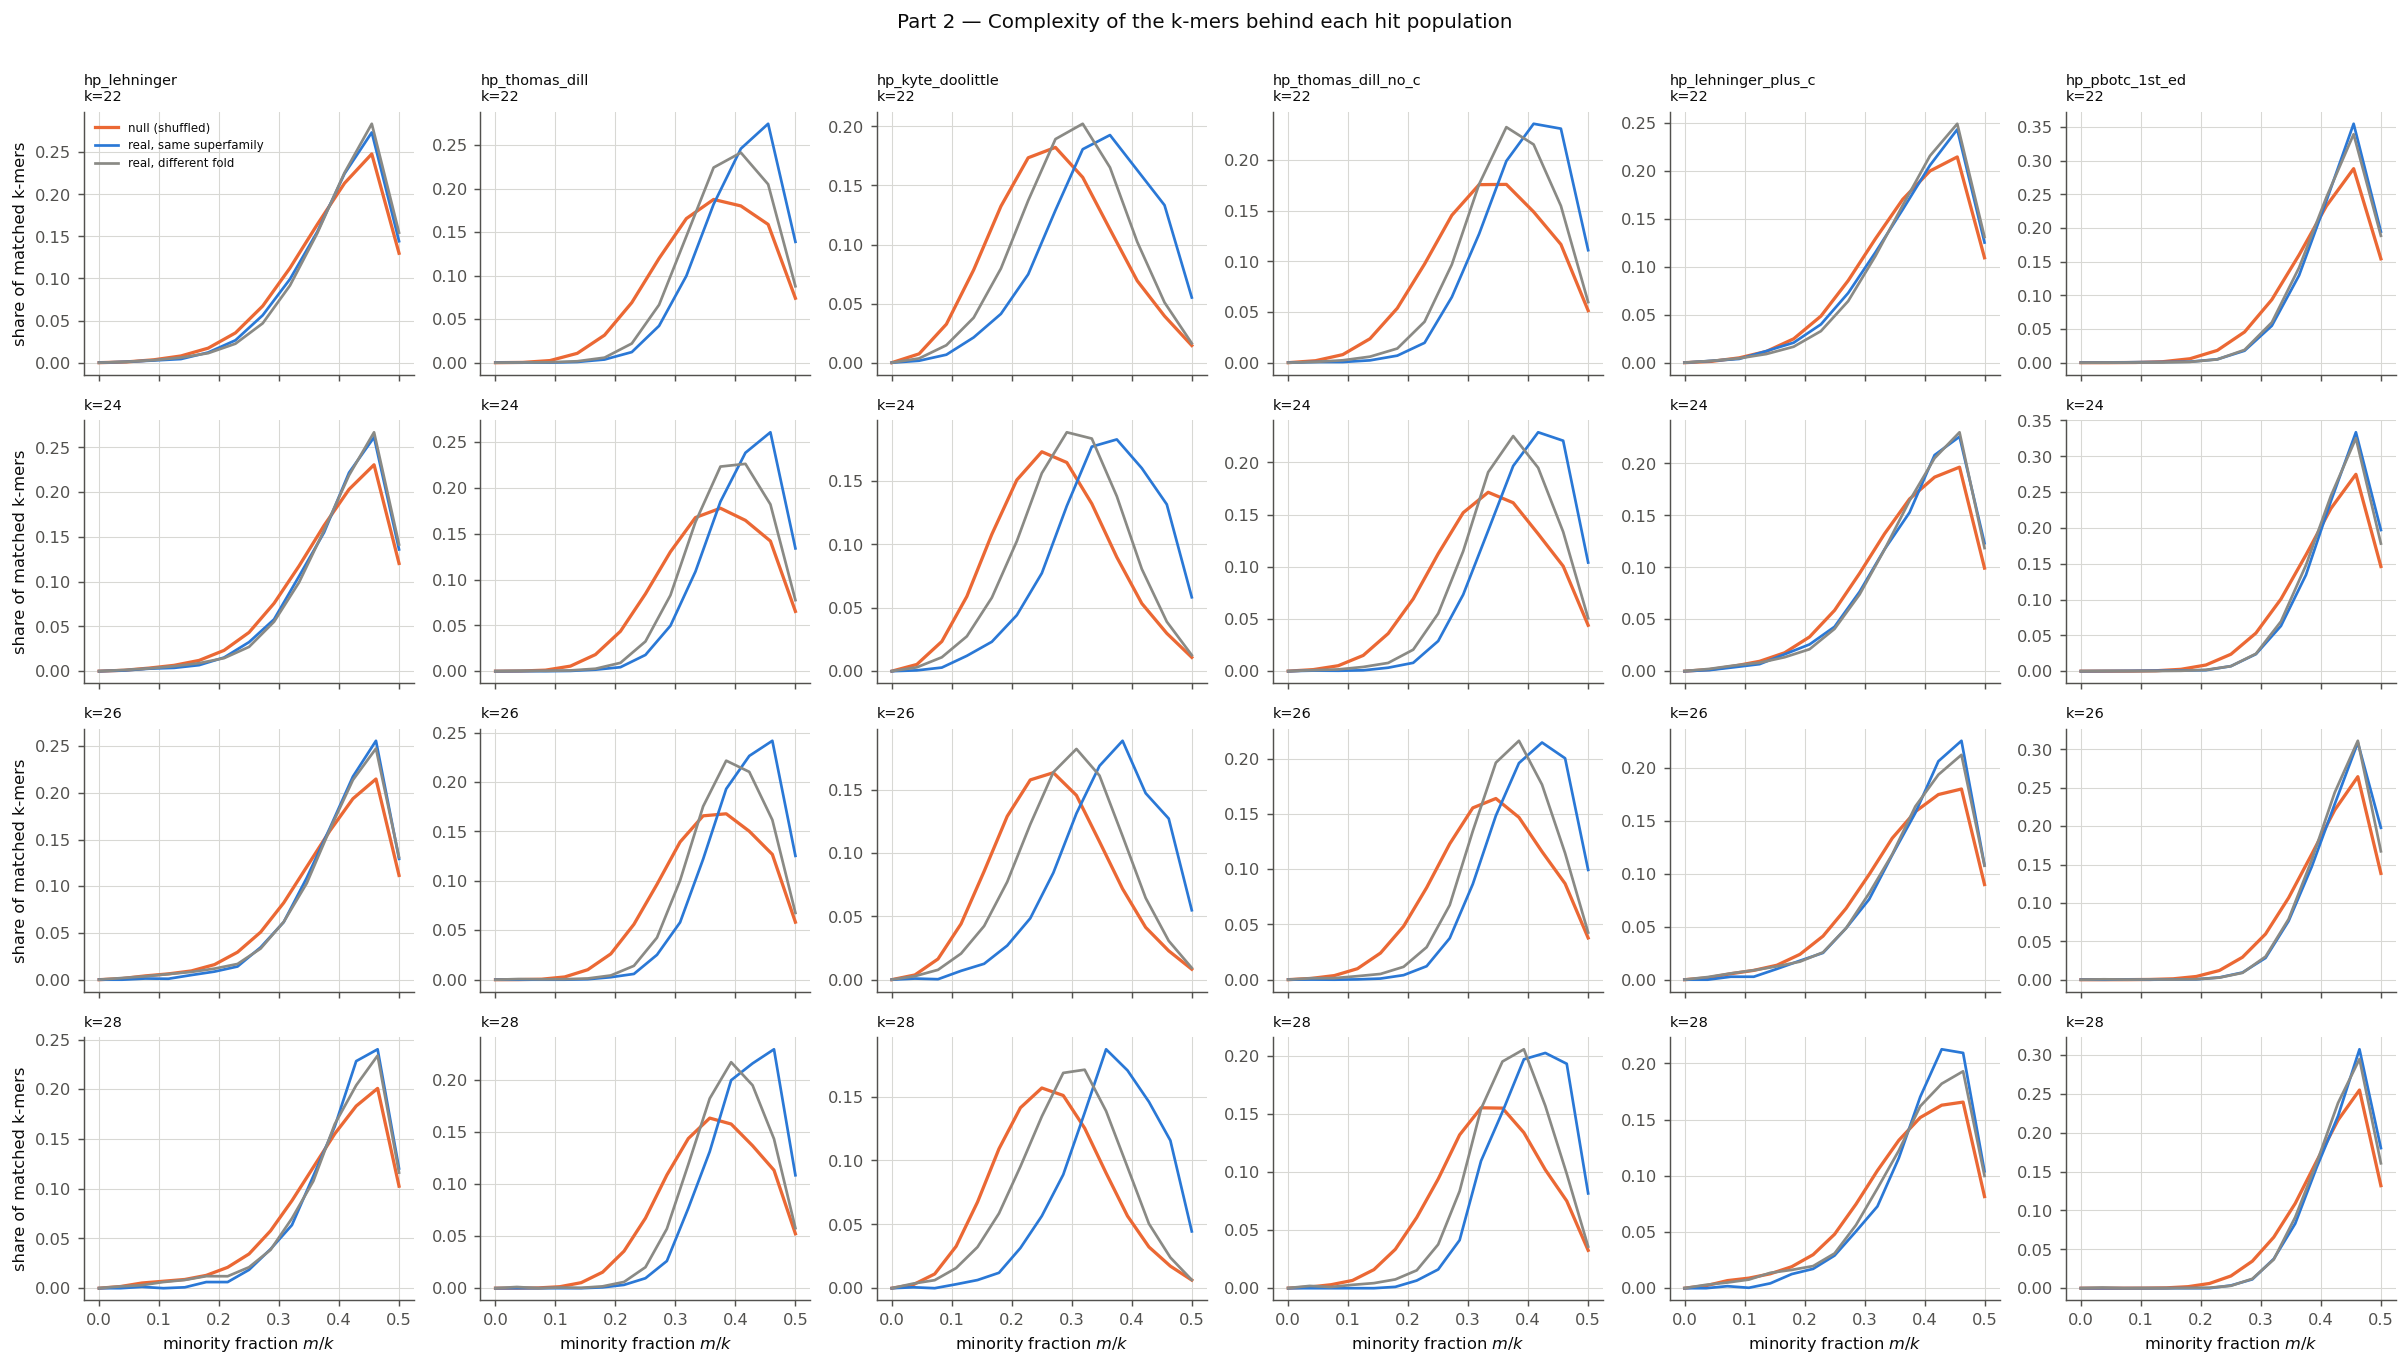

In [7]:
def kmer_level_distribution(df: pl.DataFrame, k: int) -> np.ndarray:
    # Total matched-k-mer occurrences per minority count m = 0..k//2.
    if df.is_empty():
        return np.zeros(k // 2 + 1)
    return np.array(df['m_hist'].to_list(), dtype=np.int64).sum(axis=0)


def populations(alphabet: str, k: int):
    # (null, real true-positive, real false-positive) hit frames.
    base = hits.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == k))
    null = base.filter(pl.col('seqset').str.starts_with('shuf'))
    real = base.filter(pl.col('seqset') == 'real')
    tp = real.filter(pl.col('same_superfamily').fill_null(False))
    fp = real.filter(~pl.col('same_fold').fill_null(False))
    return null, tp, fp


n_alpha = len(ALPHABETS)
fig, axes = plt.subplots(len(KSIZES), n_alpha, figsize=(3.1 * n_alpha, 2.6 * len(KSIZES)),
                         squeeze=False, sharex=True)
for r, k in enumerate(KSIZES):
    frac_axis = np.arange(k // 2 + 1) / k
    for c, alphabet in enumerate(ALPHABETS):
        ax = axes[r][c]
        null, tp, fp = populations(alphabet, k)
        for df, color, name in [(null, C_NULL, 'null (shuffled)'),
                                (tp, C_TP, 'real, same superfamily'),
                                (fp, C_REALFP, 'real, different fold')]:
            dist = kmer_level_distribution(df, k)
            total = dist.sum()
            if total == 0:
                continue
            ax.plot(frac_axis, dist / total, color=color, label=name,
                    linewidth=1.8 if name.startswith('null') else 1.5)
        ax.set_title(f'{alphabet}\nk={k}' if r == 0 else f'k={k}', loc='left', fontsize=8)
        if c == 0:
            ax.set_ylabel('share of matched k-mers')
        if r == len(KSIZES) - 1:
            ax.set_xlabel('minority fraction $m/k$')
        if r == 0 and c == 0:
            ax.legend(fontsize=6.5, loc='upper left')
fig.suptitle('Part 2 — Complexity of the k-mers behind each hit population',
             x=0.5, y=1.005, fontsize=11, ha='center')
fig.tight_layout()
fig.savefig(f'{FIG_PREFIX}_kmer_complexity_distributions.png')
plt.show()

In [8]:
# Quantify the separation rather than eyeballing the curves: the low tail is what
# a mask removes, so compare mass below a candidate fraction.
rows = []
for alphabet in ALPHABETS:
    for k in KSIZES:
        null, tp, fp = populations(alphabet, k)
        d_null, d_tp = kmer_level_distribution(null, k), kmer_level_distribution(tp, k)
        if d_null.sum() == 0 or d_tp.sum() == 0:
            continue
        frac = np.arange(k // 2 + 1) / k
        p_null, p_tp = d_null / d_null.sum(), d_tp / d_tp.sum()
        rows.append({
            'alphabet': alphabet, 'ksize': k,
            'median_frac_null': float(frac[np.searchsorted(np.cumsum(p_null), 0.5)]),
            'median_frac_tp': float(frac[np.searchsorted(np.cumsum(p_tp), 0.5)]),
            'null_mass_below_0.20': float(p_null[frac < 0.20].sum()),
            'tp_mass_below_0.20': float(p_tp[frac < 0.20].sum()),
        })
sep = pl.DataFrame(rows)
if not sep.is_empty():
    sep = sep.with_columns(
        (pl.col('null_mass_below_0.20') / pl.col('tp_mass_below_0.20').clip(1e-9))
        .round(2).alias('null:TP enrichment below 0.20')
    )
print('Low-complexity mass, null vs true positives')
print(sep)
if not sep.is_empty() and (sep['null_mass_below_0.20'] <= sep['tp_mass_below_0.20']).all():
    print('\nWARNING: null-hit k-mers are NOT enriched for low complexity relative to '
          'true positives. The premise of a complexity mask does not hold on this data.')

Low-complexity mass, null vs true positives
shape: (24, 7)
┌─────────────────────┬───────┬──────────────────┬────────────────┬──────────────────────┬────────────────────┬───────────────────────────────┐
│ alphabet            ┆ ksize ┆ median_frac_null ┆ median_frac_tp ┆ null_mass_below_0.20 ┆ tp_mass_below_0.20 ┆ null:TP enrichment below 0.20 │
│ ---                 ┆ ---   ┆ ---              ┆ ---            ┆ ---                  ┆ ---                ┆ ---                           │
│ str                 ┆ i64   ┆ f64              ┆ f64            ┆ f64                  ┆ f64                ┆ f64                           │
╞═════════════════════╪═══════╪══════════════════╪════════════════╪══════════════════════╪════════════════════╪═══════════════════════════════╡
│ hp_lehninger        ┆ 22    ┆ 0.409091         ┆ 0.409091       ┆ 0.029542             ┆ 0.020117           ┆ 1.47                          │
│ hp_lehninger        ┆ 24    ┆ 0.416667         ┆ 0.416667       ┆ 0.023028 

## Part 3 — Calibrating $K^*$ against the null

A hit survives a mask at floor $m^\*$ combined with notebook 085's shared-k-mer floor $c$
exactly when at least $c$ of its matched k-mers clear the floor:

$$\sum_{m \ge m^\*} \mathrm{hist}(m) \;\ge\; c$$

Sweeping $m^\*$ traces how fast the spurious-hit rate collapses, and — on the same axis — what
it costs in real same-superfamily hits. Rates are normalised **per query domain** so they are
comparable across alphabets and k, and averaged over the 10 shuffles.

The plan was to put $K^\*$ where the null curve crosses a target false-positive level. **On this
data that target turns out to be unreachable**, so the cell below reports the reachability check
first and then inverts the question into the form that does have an answer: *how much of the null
can this knob remove, for a true-positive cost we are willing to pay?* Chasing an unreachable
target would otherwise select a degenerate floor that masks nearly every k-mer.

In [9]:
TARGET_NULL_RETENTION = 0.01   # collapse spurious hits to <=1% of their unmasked rate
KMER_FLOOR = 1                 # c; Part 6 sweeps this jointly with m*

# Cast explicitly: run_stats is a diagonal_relaxed concat of per-task files, so
# a column can arrive as String whenever one task's schema differs.
N_QUERIES = None
if 'n_sequences' in run_stats.columns:
    _ns = run_stats['n_sequences'].cast(pl.Int64, strict=False).max()
    N_QUERIES = int(_ns) if _ns is not None else None
if N_QUERIES is None:
    # Fallback: the database size the null rate is normalised by.
    N_QUERIES = int(hits['query_domain'].n_unique())
print(f'query domains: {N_QUERIES:,}')


def survival_matrix(df: pl.DataFrame, k: int, floor_c: int = 1) -> np.ndarray:
    # Boolean (n_hits, k//2+1): does each hit survive a mask at each m*?
    # suffix[:, m] is the hit's surviving k-mer count once every k-mer with
    # minority count < m is masked.
    if df.is_empty():
        return np.zeros((0, k // 2 + 1), dtype=bool)
    arr = np.array(df['m_hist'].to_list(), dtype=np.int64)
    suffix = np.cumsum(arr[:, ::-1], axis=1)[:, ::-1]
    return suffix >= floor_c


# Consistency check: for a contiguous region the histogram must total the
# reported shared-k-mer count.
_chk = hits.filter(pl.col('ksize') == KSIZES[0]).head(2000)
if not _chk.is_empty():
    tot = np.array(_chk['m_hist'].to_list(), dtype=np.int64).sum(axis=1)
    assert (tot == _chk['n_intersecting_hashes'].to_numpy()).all(), \
        'm_hist does not sum to n_intersecting_hashes'
    print('m_hist sums to n_intersecting_hashes: OK')

curves = []
for alphabet in ALPHABETS:
    for k in KSIZES:
        null, tp, fp = populations(alphabet, k)
        if null.is_empty() or tp.is_empty():
            continue
        m_axis = np.arange(k // 2 + 1)
        # Per-shuffle null rates keep the spread across replicates visible.
        per_shuffle = []
        for s in SHUFFLE_SETS:
            sub = null.filter(pl.col('seqset') == s)
            if sub.is_empty():
                continue
            per_shuffle.append(survival_matrix(sub, k, KMER_FLOOR).sum(axis=0) / N_QUERIES)
        if not per_shuffle:
            continue
        null_rate = np.mean(per_shuffle, axis=0)
        tp_surv = survival_matrix(tp, k, KMER_FLOOR).sum(axis=0)
        for i, m in enumerate(m_axis):
            curves.append({
                'alphabet': alphabet, 'ksize': k, 'm_star': int(m),
                'minority_fraction': m / k,
                'complexity_bits': complexity_bits(k, int(m)),
                'null_hits_per_query': float(null_rate[i]),
                'null_retention': float(null_rate[i] / null_rate[0]) if null_rate[0] else np.nan,
                'tp_retention': float(tp_surv[i] / tp_surv[0]) if tp_surv[0] else np.nan,
                'null_sd_per_query': float(np.std(per_shuffle, axis=0)[i]),
            })
curve_df = pl.DataFrame(curves)
print(f'operating curves: {len(curve_df):,} rows')

query domains: 15,177


m_hist sums to n_intersecting_hashes: OK


operating curves: 324 rows


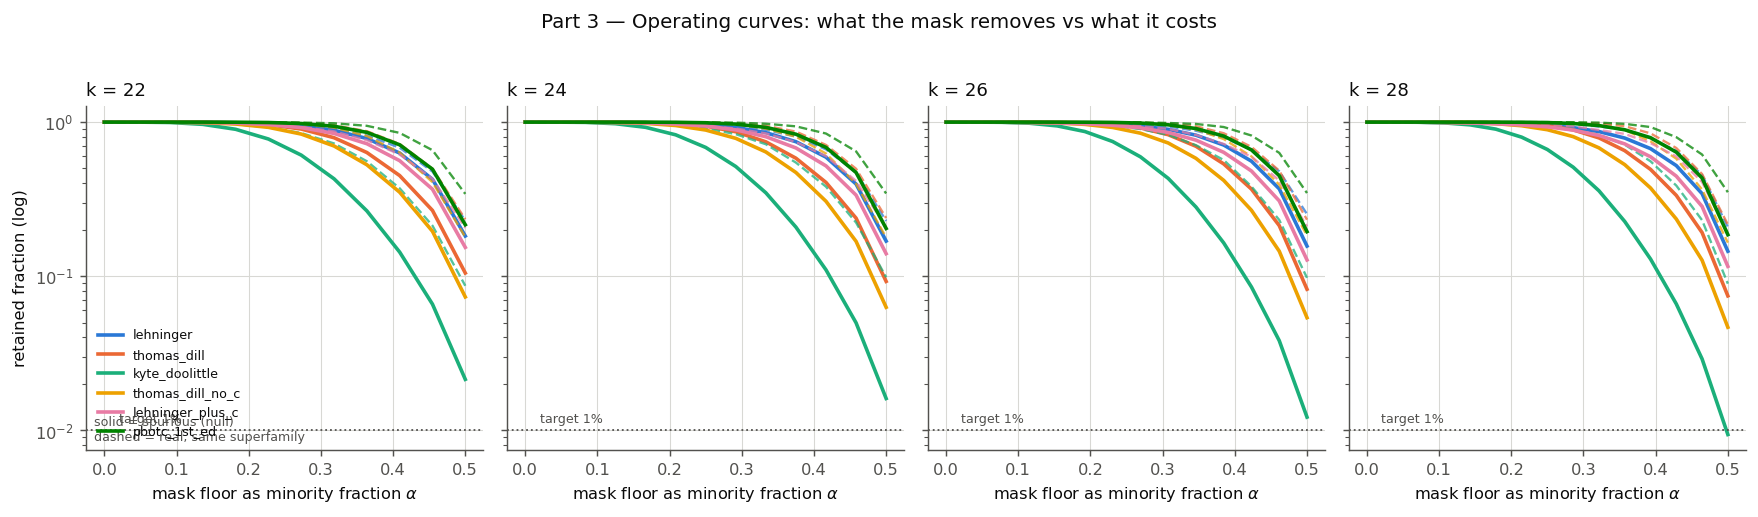

In [10]:
if curve_df.is_empty():
    print('No operating curves — pipeline output is empty.')
else:
    fig, axes = plt.subplots(1, len(KSIZES), figsize=(3.4 * len(KSIZES), 3.8),
                             squeeze=False, sharey=True)
    for j, k in enumerate(KSIZES):
        ax = axes[0][j]
        for alphabet in ALPHABETS:
            sub = curve_df.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == k)).sort('m_star')
            if sub.is_empty():
                continue
            color = ALPHABET_COLOR[alphabet]
            ax.plot(sub['minority_fraction'], sub['null_retention'], color=color,
                    label=alphabet.replace('hp_', ''))
            ax.plot(sub['minority_fraction'], sub['tp_retention'], color=color,
                    linestyle='--', linewidth=1.3, alpha=0.75)
        ax.axhline(TARGET_NULL_RETENTION, color=INK_MUTED, linewidth=1, linestyle=':')
        ax.annotate(f'target {TARGET_NULL_RETENTION:.0%}', xy=(0.02, TARGET_NULL_RETENTION),
                    xytext=(0, 4), textcoords='offset points', fontsize=7, color=INK_MUTED)
        ax.set_yscale('log')
        ax.set_xlabel('mask floor as minority fraction $\\alpha$')
        ax.set_title(f'k = {k}', loc='left')
        if j == 0:
            ax.set_ylabel('retained fraction (log)')
            ax.legend(fontsize=7, loc='lower left')
    axes[0][0].annotate('solid = spurious (null)\ndashed = real, same superfamily',
                        xy=(0.02, 0.02), xycoords='axes fraction', fontsize=7,
                        color=INK_MUTED, va='bottom')
    fig.suptitle('Part 3 — Operating curves: what the mask removes vs what it costs',
                 x=0.5, y=1.03, fontsize=11, ha='center')
    fig.tight_layout()
    fig.savefig(f'{FIG_PREFIX}_operating_curves.png')
    plt.show()

In [11]:
# --- First: can the null-retention target be reached at all? ---
reach = []
for alphabet in ALPHABETS:
    for k in KSIZES:
        sub = (curve_df.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == k))
               .sort('m_star'))
        if sub.is_empty():
            continue
        got = sub.filter(pl.col('null_retention') <= TARGET_NULL_RETENTION)
        reach.append({
            'alphabet': alphabet, 'ksize': k,
            'reached_target': not got.is_empty(),
            'alpha_at_target': round(got.row(0, named=True)['minority_fraction'], 4)
            if not got.is_empty() else None,
            'tp_left_at_target': round(got.row(0, named=True)['tp_retention'], 4)
            if not got.is_empty() else None,
            'best_null_retention': round(float(sub['null_retention'].min()), 4),
        })
reach_df = pl.DataFrame(reach)
n_reached = int(reach_df['reached_target'].sum())
print(f'Combos reaching null retention <= {TARGET_NULL_RETENTION:.0%}: '
      f'{n_reached} / {len(reach_df)}')
if n_reached < len(reach_df):
    print('The target is NOT generally reachable with this knob. Best achievable '
          'null retention per combo (at any floor, including masking everything):')
    print(reach_df.select(['alphabet', 'ksize', 'best_null_retention',
                           'reached_target', 'tp_left_at_target'])
          .sort(['alphabet', 'ksize']))

# --- The usable reading: the frontier, budgeted by what it costs in TPs ---
# Chasing an unreachable null target picks a degenerate floor that masks almost
# everything. Inverting the question - "how much null can be removed for a TP
# cost I am willing to pay?" - always has an answer and is the shippable form.
TP_BUDGETS = [0.99, 0.95, 0.90]
frontier_rows = []
for alphabet in ALPHABETS:
    for k in KSIZES:
        sub = (curve_df.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == k))
               .sort('m_star'))
        if sub.is_empty():
            continue
        for budget in TP_BUDGETS:
            afford = sub.filter(pl.col('tp_retention') >= budget)
            if afford.is_empty():
                continue
            row = afford.sort('m_star', descending=True).row(0, named=True)
            frontier_rows.append({
                'alphabet': alphabet, 'ksize': k, 'tp_budget': budget,
                'm_star': row['m_star'],
                'alpha': round(row['minority_fraction'], 4),
                'K_star_bits': round(row['complexity_bits'], 4),
                'tp_retention': round(row['tp_retention'], 4),
                'null_retention': round(row['null_retention'], 4),
                'null_removed': round(1 - row['null_retention'], 4),
            })
frontier = pl.DataFrame(frontier_rows)
print(f'\nFrontier: largest mask floor affordable at each true-positive budget '
      f'(shared-k-mer floor c = {KMER_FLOOR})')
print(frontier.sort(['tp_budget', 'alphabet', 'ksize']))

# `calib` is what Part 4 tests for invariance: the 95%-TP-budget operating point.
calib = (frontier.filter(pl.col('tp_budget') == 0.95)
         .with_columns(pl.lit(True).alias('reached_target'))
         .drop('tp_budget'))
if not calib.is_empty():
    print(f'\nAt the 95% TP budget: alpha median {calib["alpha"].median():.3f} '
          f'(range {calib["alpha"].min():.3f}-{calib["alpha"].max():.3f}), '
          f'K* median {calib["K_star_bits"].median():.3f}')
    print(f'null removed: median {calib["null_removed"].median():.1%} '
          f'(range {calib["null_removed"].min():.1%}-{calib["null_removed"].max():.1%})')

Combos reaching null retention <= 1%: 1 / 24
The target is NOT generally reachable with this knob. Best achievable null retention per combo (at any floor, including masking everything):
shape: (24, 5)
┌─────────────────────┬───────┬─────────────────────┬────────────────┬───────────────────┐
│ alphabet            ┆ ksize ┆ best_null_retention ┆ reached_target ┆ tp_left_at_target │
│ ---                 ┆ ---   ┆ ---                 ┆ ---            ┆ ---               │
│ str                 ┆ i64   ┆ f64                 ┆ bool           ┆ f64               │
╞═════════════════════╪═══════╪═════════════════════╪════════════════╪═══════════════════╡
│ hp_kyte_doolittle   ┆ 22    ┆ 0.0214              ┆ false          ┆ null              │
│ hp_kyte_doolittle   ┆ 24    ┆ 0.0161              ┆ false          ┆ null              │
│ hp_kyte_doolittle   ┆ 26    ┆ 0.0122              ┆ false          ┆ null              │
│ hp_kyte_doolittle   ┆ 28    ┆ 0.0094              ┆ true           ┆ 

## Part 4 — Does the calibrated $\alpha$ actually hold still across $k$?

This is the load-bearing claim. If the calibrated $\alpha$ is roughly flat in $k$ while the
calibrated *count* $m^\*$ climbs, then the fraction is the invariant and phrasing the rule as
a count would have quietly changed the mask's meaning at every $k$. If instead $\alpha$ drifts
and $m^\*$ is flat, the count is the right knob and Part 0's argument does not survive contact
with the data. Both outcomes are legible on this figure.

Each alphabet also has a different H:P residue split (7/13 for kyte-doolittle up to 11/9 for
lehninger-plus-c), so the panel on the right checks whether the calibrated cutoff tracks that
background composition — if it does, $K^\*$ is not one universal constant but a per-alphabet one.

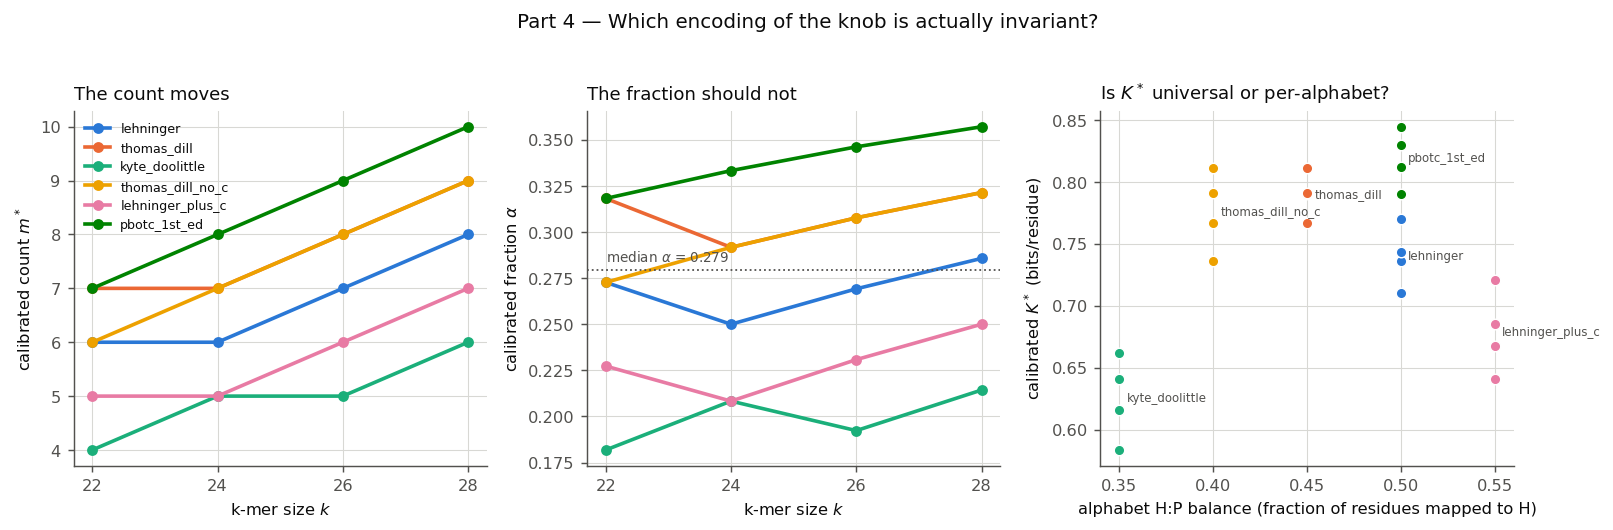

Variation across k (lower = more invariant)
shape: (6, 3)
┌─────────────────────┬──────────┬───────────┐
│ alphabet            ┆ cv_alpha ┆ cv_m_star │
│ ---                 ┆ ---      ┆ ---       │
│ str                 ┆ f64      ┆ f64       │
╞═════════════════════╪══════════╪═══════════╡
│ hp_kyte_doolittle   ┆ 0.0745   ┆ 0.1633    │
│ hp_lehninger        ┆ 0.0548   ┆ 0.1418    │
│ hp_lehninger_plus_c ┆ 0.0746   ┆ 0.1665    │
│ hp_pbotc_1st_ed     ┆ 0.0495   ┆ 0.1519    │
│ hp_thomas_dill      ┆ 0.0432   ┆ 0.1235    │
│ hp_thomas_dill_no_c ┆ 0.0703   ┆ 0.1721    │
└─────────────────────┴──────────┴───────────┘


In [12]:
if calib.filter(pl.col('reached_target')).is_empty():
    print('No alphabet/k reached the target — nothing to plot.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
    ok = calib.filter(pl.col('reached_target'))

    # --- left: calibrated count climbs with k ---
    ax = axes[0]
    for alphabet in ALPHABETS:
        sub = ok.filter(pl.col('alphabet') == alphabet).sort('ksize')
        if sub.is_empty():
            continue
        ax.plot(sub['ksize'], sub['m_star'], 'o-', color=ALPHABET_COLOR[alphabet],
                label=alphabet.replace('hp_', ''))
    ax.set_xlabel('k-mer size $k$'); ax.set_ylabel('calibrated count $m^*$')
    ax.set_title('The count moves', loc='left')
    ax.set_xticks(KSIZES)
    ax.legend(fontsize=7)

    # --- middle: calibrated fraction should not ---
    ax = axes[1]
    for alphabet in ALPHABETS:
        sub = ok.filter(pl.col('alphabet') == alphabet).sort('ksize')
        if sub.is_empty():
            continue
        ax.plot(sub['ksize'], sub['alpha'], 'o-', color=ALPHABET_COLOR[alphabet],
                label=alphabet.replace('hp_', ''))
    med = ok['alpha'].median()
    ax.axhline(med, color=INK_MUTED, linestyle=':', linewidth=1)
    ax.annotate(f'median $\\alpha$ = {med:.3f}', xy=(KSIZES[0], med), xytext=(0, 5),
                textcoords='offset points', fontsize=7.5, color=INK_MUTED)
    ax.set_xlabel('k-mer size $k$'); ax.set_ylabel('calibrated fraction $\\alpha$')
    ax.set_title('The fraction should not', loc='left')
    ax.set_xticks(KSIZES)

    # --- right: does K* track the alphabet's own H:P balance? ---
    ax = axes[2]
    for alphabet in ALPHABETS:
        sub = ok.filter(pl.col('alphabet') == alphabet)
        if sub.is_empty():
            continue
        hf = h_fraction(alphabet.replace('_', '-'))
        ax.scatter([hf] * len(sub), sub['K_star_bits'], color=ALPHABET_COLOR[alphabet],
                   s=34, label=alphabet.replace('hp_', ''), zorder=3,
                   edgecolor='white', linewidth=0.8)
        ax.annotate(alphabet.replace('hp_', ''), xy=(hf, sub['K_star_bits'].mean()),
                    xytext=(4, 0), textcoords='offset points', fontsize=6.5,
                    color=INK_MUTED, va='center')
    ax.set_xlabel('alphabet H:P balance (fraction of residues mapped to H)')
    ax.set_ylabel('calibrated $K^*$ (bits/residue)')
    ax.set_title('Is $K^*$ universal or per-alphabet?', loc='left')

    fig.suptitle('Part 4 — Which encoding of the knob is actually invariant?',
                 x=0.5, y=1.03, fontsize=11, ha='center')
    fig.tight_layout()
    fig.savefig(f'{FIG_PREFIX}_alpha_invariance.png')
    plt.show()

    # The claim, as a number: coefficient of variation across k, per alphabet.
    drift = (ok.group_by('alphabet').agg([
        (pl.col('alpha').std() / pl.col('alpha').mean()).round(4).alias('cv_alpha'),
        (pl.col('m_star').std() / pl.col('m_star').mean()).round(4).alias('cv_m_star'),
    ]).sort('alphabet'))
    print('Variation across k (lower = more invariant)')
    print(drift)

## Part 5 — Cross-check: the frequency knee

Independent of any shuffle. Build the HP k-mer frequency table over the real SCOPe40 database
and plot per-k-mer *document frequency* — the share of domains containing that k-mer at least
once, which is what containment and the Poisson model actually see — against minority count.

The mechanism predicts a sharp knee: poly-dominant compositions are spread over very few
distinct k-mers, so each individual one is common, while higher-complexity compositions are
spread over exponentially more and each is rare. $m^\*$ belongs just above the knee. If this
lands in the same neighbourhood as Part 3's shuffle-calibrated value, two independent routes
agree and the number is not an artefact of either.

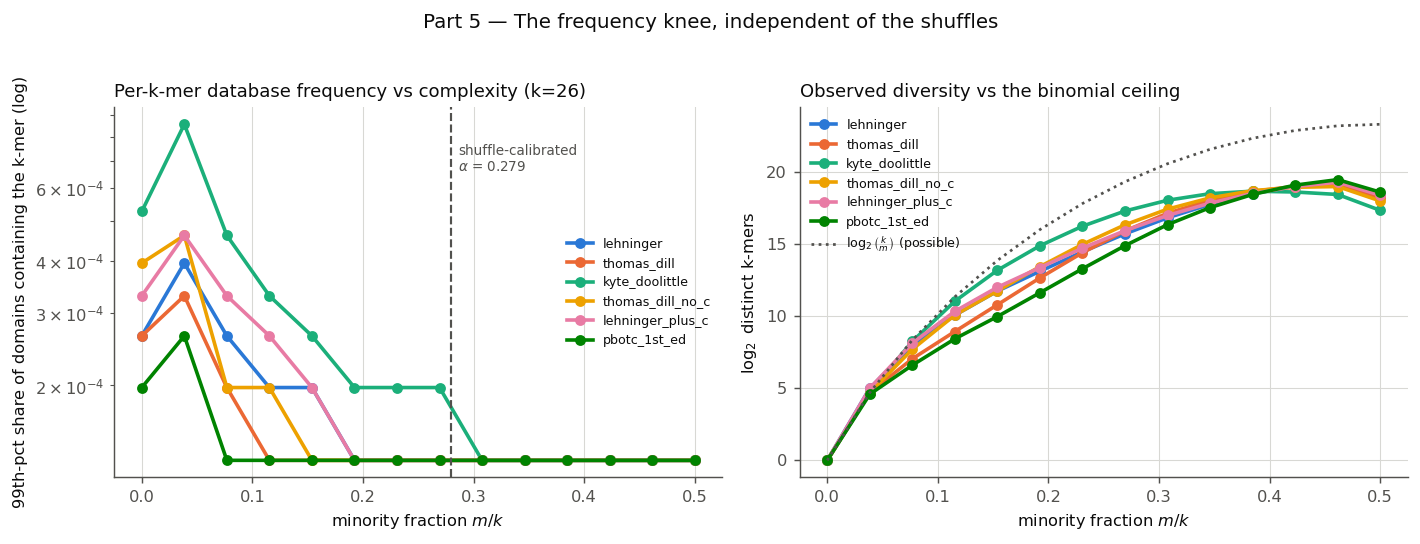

Frequency table, k=26
shape: (84, 7)
┌─────────────────────┬────────────────┬───────────────────┬─────────────────┬─────────────────────┬───────────────────┬──────────────────┐
│ alphabet            ┆ minority_count ┆ minority_fraction ┆ complexity_bits ┆ n_distinct_observed ┆ mean_doc_fraction ┆ p99_doc_fraction │
│ ---                 ┆ ---            ┆ ---               ┆ ---             ┆ ---                 ┆ ---               ┆ ---              │
│ str                 ┆ i32            ┆ f64               ┆ f64             ┆ u32                 ┆ f64               ┆ f64              │
╞═════════════════════╪════════════════╪═══════════════════╪═════════════════╪═════════════════════╪═══════════════════╪══════════════════╡
│ hp_kyte_doolittle   ┆ 0              ┆ 0.0               ┆ 0.0             ┆ 1                   ┆ 0.000527          ┆ 0.000527         │
│ hp_kyte_doolittle   ┆ 1              ┆ 0.038462          ┆ 0.180786        ┆ 26                  ┆ 0.000481          ┆ 0.

In [13]:
if freq_by_m.is_empty():
    print('No frequency table found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    K_FOCUS = 26 if 26 in KSIZES else KSIZES[len(KSIZES) // 2]

    # --- left: the knee itself ---
    ax = axes[0]
    for alphabet in ALPHABETS:
        sub = (freq_by_m.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == K_FOCUS))
               .sort('minority_count'))
        if sub.is_empty():
            continue
        ax.plot(sub['minority_fraction'], sub['p99_doc_fraction'],
                'o-', color=ALPHABET_COLOR[alphabet], label=alphabet.replace('hp_', ''))
    ax.set_yscale('log')
    ax.set_xlabel('minority fraction $m/k$')
    ax.set_ylabel('99th-pct share of domains containing the k-mer (log)')
    ax.set_title(f'Per-k-mer database frequency vs complexity (k={K_FOCUS})', loc='left')
    ax.legend(fontsize=7)

    if not calib.filter(pl.col('reached_target')).is_empty():
        med_alpha = calib.filter(pl.col('reached_target'))['alpha'].median()
        ax.axvline(med_alpha, color=INK_MUTED, linestyle='--', linewidth=1.2)
        ax.annotate(f'shuffle-calibrated\n$\\alpha$ = {med_alpha:.3f}',
                    xy=(med_alpha, ax.get_ylim()[1]), xytext=(4, -20),
                    textcoords='offset points', fontsize=7.5, color=INK_MUTED, va='top')

    # --- right: saturation — observed vs combinatorially possible ---
    ax = axes[1]
    for alphabet in ALPHABETS:
        sub = (freq_by_m.filter((pl.col('alphabet') == alphabet) & (pl.col('ksize') == K_FOCUS))
               .sort('minority_count'))
        if sub.is_empty():
            continue
        observed = np.log2(np.maximum(sub['n_distinct_observed'].to_numpy(), 1))
        ax.plot(sub['minority_fraction'], observed, 'o-',
                color=ALPHABET_COLOR[alphabet], label=alphabet.replace('hp_', ''))
    ks = freq_by_m.filter(pl.col('ksize') == K_FOCUS)
    if not ks.is_empty():
        # The combinatorial ceiling: how many distinct k-mers could exist at
        # each composition, against which the observed diversity saturates.
        m_vals = sorted(set(ks['minority_count'].to_list()))
        ax.plot([m / K_FOCUS for m in m_vals],
                [log2(comb(K_FOCUS, int(m))) for m in m_vals],
                color=INK_MUTED, linestyle=':', linewidth=1.5,
                label='$\\log_2\\binom{k}{m}$ (possible)')
    ax.set_xlabel('minority fraction $m/k$')
    ax.set_ylabel('$\\log_2$ distinct k-mers')
    ax.set_title('Observed diversity vs the binomial ceiling', loc='left')
    ax.legend(fontsize=7)

    fig.suptitle('Part 5 — The frequency knee, independent of the shuffles',
                 x=0.5, y=1.03, fontsize=11, ha='center')
    fig.tight_layout()
    fig.savefig(f'{FIG_PREFIX}_frequency_knee.png')
    plt.show()

    print(f'Frequency table, k={K_FOCUS}')
    print(freq_by_m.filter(pl.col('ksize') == K_FOCUS)
          .select(['alphabet', 'minority_count', 'minority_fraction', 'complexity_bits',
                   'n_distinct_observed', 'mean_doc_fraction', 'p99_doc_fraction'])
          .sort(['alphabet', 'minority_count']))

## Part 6 — Joint operating point with notebook 085's shared-k-mer floor

085 recommended gating on `n_intersecting_hashes` ≥ 2–3. That filter and this mask attack the
same noise — a coincidental single k-mer — so they cannot be assumed to compose. Sweeping both
jointly shows whether the mask still buys anything once the count floor is in place, and
whether the two together cost more true positives than either alone.

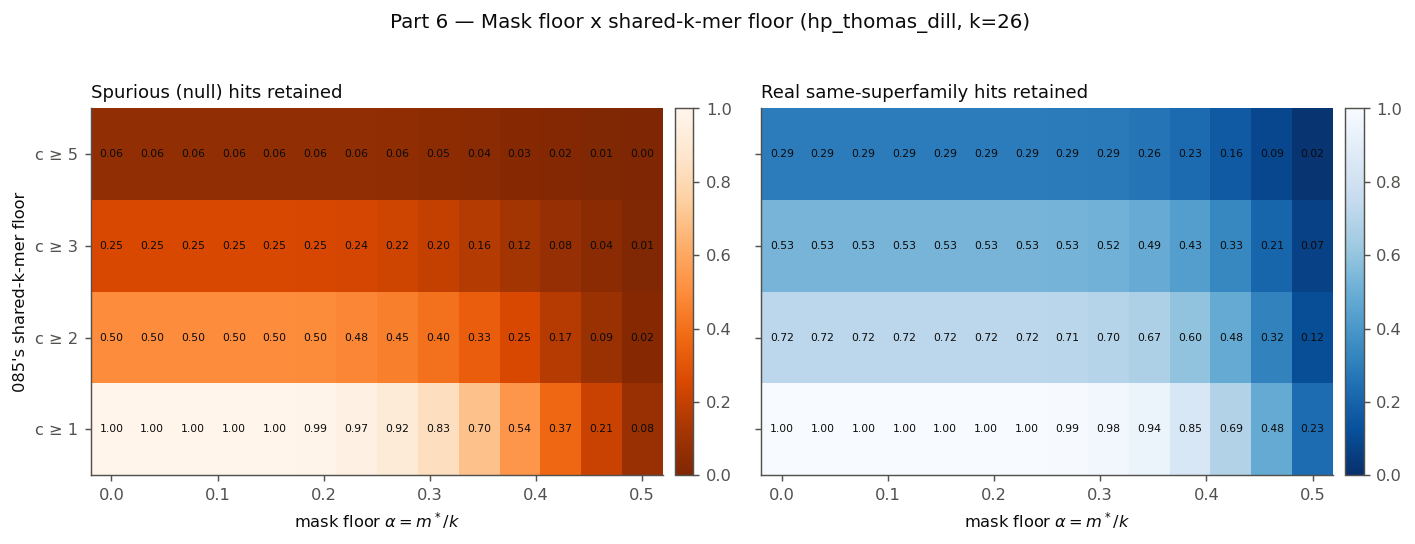

Configurations keeping >=95% of true positives, ranked by null suppression
shape: (9, 5)
┌──────────────┬────────┬───────┬───────────────┬─────────────┐
│ kmer_floor_c ┆ m_star ┆ alpha ┆ null_retained ┆ tp_retained │
│ ---          ┆ ---    ┆ ---   ┆ ---           ┆ ---         │
│ i64          ┆ i64    ┆ f64   ┆ f64           ┆ f64         │
╞══════════════╪════════╪═══════╪═══════════════╪═════════════╡
│ 1            ┆ 8      ┆ 0.308 ┆ 0.8285        ┆ 0.9752      │
│ 1            ┆ 7      ┆ 0.269 ┆ 0.9165        ┆ 0.9938      │
│ 1            ┆ 6      ┆ 0.231 ┆ 0.9662        ┆ 0.9987      │
│ 1            ┆ 5      ┆ 0.192 ┆ 0.9889        ┆ 1.0         │
│ 1            ┆ 4      ┆ 0.154 ┆ 0.9973        ┆ 1.0         │
│ 1            ┆ 3      ┆ 0.115 ┆ 0.9996        ┆ 1.0         │
│ 1            ┆ 2      ┆ 0.077 ┆ 0.9999        ┆ 1.0         │
│ 1            ┆ 0      ┆ 0.0   ┆ 1.0           ┆ 1.0         │
│ 1            ┆ 1      ┆ 0.038 ┆ 1.0           ┆ 1.0         │
└──────────────

In [14]:
JOINT_ALPHABET = 'hp_thomas_dill' if 'hp_thomas_dill' in ALPHABETS else (ALPHABETS[0] if ALPHABETS else None)
K_JOINT = 26 if 26 in KSIZES else (KSIZES[len(KSIZES) // 2] if KSIZES else None)

if JOINT_ALPHABET is None or K_JOINT is None:
    print('Not enough data for the joint sweep.')
else:
    null, tp, fp = populations(JOINT_ALPHABET, K_JOINT)
    c_floors = [1, 2, 3, 5]
    m_axis = np.arange(K_JOINT // 2 + 1)
    grid_null = np.full((len(c_floors), len(m_axis)), np.nan)
    grid_tp = np.full((len(c_floors), len(m_axis)), np.nan)

    for i, c in enumerate(c_floors):
        if not null.is_empty():
            base = survival_matrix(null, K_JOINT, 1).sum(axis=0)[0]
            if base:
                grid_null[i] = survival_matrix(null, K_JOINT, c).sum(axis=0) / base
        if not tp.is_empty():
            base = survival_matrix(tp, K_JOINT, 1).sum(axis=0)[0]
            if base:
                grid_tp[i] = survival_matrix(tp, K_JOINT, c).sum(axis=0) / base

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharex=True, sharey=True)
    # Sequential ramp: one hue, light->dark, for a magnitude.
    for ax, grid, title, cmap in [
        (axes[0], grid_null, 'Spurious (null) hits retained', 'Oranges_r'),
        (axes[1], grid_tp, 'Real same-superfamily hits retained', 'Blues_r'),
    ]:
        im = ax.imshow(grid, aspect='auto', origin='lower', cmap=cmap,
                       vmin=0, vmax=1, extent=[-0.5 / K_JOINT, (len(m_axis) - 0.5) / K_JOINT,
                                               -0.5, len(c_floors) - 0.5])
        ax.set_yticks(range(len(c_floors)), [f'c ≥ {c}' for c in c_floors])
        ax.set_xlabel('mask floor $\\alpha = m^*/k$')
        ax.set_title(title, loc='left')
        ax.grid(False)
        for i in range(len(c_floors)):
            for j in range(0, len(m_axis), max(1, len(m_axis) // 8)):
                v = grid[i, j]
                if not np.isnan(v):
                    ax.text(j / K_JOINT, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=6, color=INK)
        fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    axes[0].set_ylabel("085's shared-k-mer floor")
    fig.suptitle(f'Part 6 — Mask floor x shared-k-mer floor ({JOINT_ALPHABET}, k={K_JOINT})',
                 x=0.5, y=1.03, fontsize=11, ha='center')
    fig.tight_layout()
    fig.savefig(f'{FIG_PREFIX}_joint_operating_point.png')
    plt.show()

    rows = []
    for i, c in enumerate(c_floors):
        for j, m in enumerate(m_axis):
            if np.isnan(grid_null[i, j]) or np.isnan(grid_tp[i, j]):
                continue
            rows.append({'kmer_floor_c': c, 'm_star': int(m), 'alpha': round(m / K_JOINT, 3),
                         'null_retained': round(float(grid_null[i, j]), 4),
                         'tp_retained': round(float(grid_tp[i, j]), 4)})
    joint = pl.DataFrame(rows)
    if not joint.is_empty():
        print('Configurations keeping >=95% of true positives, ranked by null suppression')
        print(joint.filter(pl.col('tp_retained') >= 0.95)
              .sort('null_retained').head(15))

## Verdict

Full run: 10 dipeptide-preserving shuffles x 6 HP alphabets x k=22,24,26,28 on SCOPe40
(15_177 domains), 106.9M hits. The headline is **partly negative, and the negative part is the
more useful half.**

**The null is sound.** Real hits carry a fold signal that strengthens with k (same-fold share
1.7% → 7.8% from k=22 to k=28, depending on alphabet); shuffled hits sit flat at ~1.1–1.3%,
i.e. at the base rate. Composition and dipeptide counts are preserved exactly in all 10
shuffles, and kmerseek's own `moltype_seq` reproduces the Python HP tables with zero
mismatches across all 264 tasks.

**A sobering context number.** Shuffled databases produce *as many hits as the real one*
(e.g. kyte-doolittle k=22: 1.14M shuffled vs 1.04M real). At these k, the overwhelming
majority of raw kmerseek hits on SCOPe40 are chance collisions — the fold signal lives in a
few per cent of the output. That is the problem any filter is trying to address.

**The premise holds, but it is a tail effect and it is alphabet-dependent.** Null-hit k-mers
*are* enriched for low complexity relative to true positives, below a minority fraction of
0.20:

| alphabet | null:TP enrichment (k=22 → k=28) |
|---|---|
| hp_thomas_dill | 9.6× → 28.1× |
| hp_kyte_doolittle | 3.5× → 10.1× |
| hp_lehninger | 1.5× → 4.3× |

Enrichment is strongest for **hp_thomas_dill**, the designated best alphabet — good news for
where the mask would ship. But the shift is in the tail, not the bulk: the *median* null k-mer
sits at minority fraction 0.25–0.42 (alphabet-dependent) against 0.36–0.43 for true positives,
and only 2–28% of null k-mer mass falls below 0.20 at all. **Most of the null is
ordinary-complexity k-mers colliding by chance, not low-complexity k-mers.** Low complexity is
a real, enriched, but small minority of the noise.

**Therefore the original calibration target is unreachable.** "Set $K^\*$ where the shuffle-hit
rate collapses below the target FP level" cannot be executed at a 1% target: 23 of 24
alphabet/k combos never reach it at any floor, and the single one that does
(kyte-doolittle k=28) gets there only by masking essentially everything, keeping 8.9% of true
positives. This is not a tuning failure — it is the measurement telling us the knob does not
control the dominant noise term.

**What the knob is actually worth.** Inverting to a true-positive budget gives a usable, honest
answer. At hp_thomas_dill k=26 with no shared-k-mer floor:

| $\alpha$ | $m^\*$ | null removed | TP retained |
|---|---|---|---|
| 0.192 | 5 | 1.1% | 100.0% |
| 0.231 | 6 | 3.4% | 99.9% |
| 0.269 | 7 | 8.4% | 99.4% |
| 0.308 | 8 | 17.2% | 97.5% |

So α ≈ 0.27–0.31 (K\* ≈ 0.74–0.79 bits/residue) is the sensible operating band: it removes
8–17% of spurious hits for well under 3% of true positives. Useful, cheap, and **not** a
replacement for a primary filter.

**Recommendation.**

1. **Ship the mask as a fraction, α ≈ 0.27–0.31, via $m^\*(k) = \min\{m : \tfrac1k\log_2\binom{k}{m} \ge K^\*\}$**
   with $K^\*$ ≈ 0.75 bits/residue — using the exact binomial form, not $\lceil \alpha k\rceil$,
   so the small-k correction is right. Treat it as a cheap pre-filter that shrinks the candidate
   set, not as the significance gate.
2. **Keep notebook 085's `n_intersecting_hashes` ≥ 2–3 as the primary gate.** It targets the
   dominant mechanism (chance collision of normal-complexity k-mers); this mask does not.
3. **Set $K^\*$ per alphabet, not globally** — the enrichment spread (1.5× to 28×) is far too
   wide to justify one constant, and it tracks the alphabet's H:P balance (Part 4, right panel).

**Caveats worth stating.** (i) The k=22–28 window is too narrow to empirically adjudicate
fraction-vs-count (Part 0: only ~1.2× separation over this range vs ~4.1× over k=12–50) — the
fraction framing here rests on the combinatorics, not on these runs. (ii) All numbers are
SCOPe40 domains; full-length genes with real disordered regions should overproduce
low-complexity k-mers relative to excised domains, so this is plausibly a **lower bound** on
what the mask buys genome-wide. Re-running this null on the human–mouse ortholog set would
test that directly and is the obvious follow-up.